# SHAP Explainability — Phase 4

**Phase 4 scope for this notebook: SHAP-based explainability on the chosen XGBoost model only.**
Isolation Forest anomaly detection (also listed under Phase 4 in `CLAUDE.md`) is explicitly
**out of scope here** and deferred to its own notebook.

Uses the same leakage-safe feature pipeline (`ml/src/preprocessing.py`) and the same chronological
split (`ml/src/split.py`, adjusted cutoff) as every prior notebook. No model has been serialized in
any earlier notebook (`04_xgboost.ipynb` and `05_model_comparison.ipynb` both retrain from scratch
each time), so the chosen XGBoost configuration is retrained here too, from the exact documented
hyperparameters and `random_state=42` — reproducing Phase 3's numbers rather than introducing a new
source of variation. **This notebook is the first to serialize anything**: the trained model and a
fitted SHAP explainer are saved to `ml/models/` at the end, specifically so the backend can reuse
them later for real-time per-prediction explanations (see the final section).

This notebook resolves a question `CLAUDE.md` has flagged since Phase 2: `is_merchant_dest` and
`type_PAYMENT` are perfectly collinear in PaySim, and the two tree models split credit between them
in two different, unprincipled-looking ways (Random Forest: uneven but nonzero on both sides;
XGBoost: **all** credit on `is_merchant_dest`, exactly zero on `type_PAYMENT`). Does SHAP resolve
this more sensibly, or does it inherit the same instability? See the "Collinearity resolution"
section below for the answer — it is more subtle than a simple yes/no.

In [1]:
import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
shap.initjs()

### Load data and import the project's own preprocessing/split modules

Same repo-root-finding pattern as every earlier notebook.

In [ ]:
def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".git").exists() or (parent / ".repo-root").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (looked for .git or .repo-root)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "ml" / "src"))

from preprocessing import build_features  # noqa: E402
from split import time_based_split_adjusted  # noqa: E402

raw_csv = next((REPO_ROOT / "ml" / "data" / "raw").glob("*.csv"))
df = pd.read_csv(raw_csv)
print(f"Loaded {raw_csv.name}: {df.shape[0]:,} rows")

## Split and features

Same **adjusted** cutoff (`time_based_split_adjusted`, step ≤ 575) and the same
`build_features()` call, split-then-transform, as every prior notebook. Not re-derived or
re-justified here — see `CLAUDE.md` ("Time-Based Split Methodology") for the full rationale.

In [3]:
train_df, test_df, cutoff_used = time_based_split_adjusted(df)
print(f"Adjusted cutoff: step <= {cutoff_used}")

X_train, y_train, feature_columns = build_features(train_df)
X_test, y_test, _ = build_features(test_df)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"X_train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"X_test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")
print(f"\nFeature columns: {feature_columns}")

Adjusted cutoff: step <= 575


X_train: (6200317, 12), fraud rate 0.1026%
X_test:  (162021, 12), fraud rate 0.9702%

Feature columns: ['oldbalanceOrg', 'oldbalanceDest', 'amount', 'hour_of_day', 'day_of_week', 'amount_to_balance_ratio', 'is_merchant_dest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## Retrain the chosen XGBoost model

Exact hyperparameters from `04_xgboost.ipynb` / `05_model_comparison.ipynb`: `n_estimators=200`,
`max_depth=6`, `learning_rate=0.1`, `scale_pos_weight` computed from the actual train fold,
`random_state=42`. PR-AUC is checked against the documented **0.989184** below to confirm this is
the same model, not a new one.

In [4]:
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="aucpr",
)
xgb.fit(X_train, y_train)

proba = xgb.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, proba)
print(f"scale_pos_weight = {scale_pos_weight:.4f}")
print(f"PR-AUC: {pr_auc:.6f}  (Phase 3 documented value: 0.989184)")
assert abs(pr_auc - 0.989184) < 1e-4, "Retrained model does not match Phase 3's XGBoost"
print("Reproduction confirmed -- this is the same model Phase 3 chose.")

scale_pos_weight = 974.0459
PR-AUC: 0.989184  (Phase 3 documented value: 0.989184)
Reproduction confirmed -- this is the same model Phase 3 chose.


## Re-derive the chosen threshold (≈0.6145)

`CLAUDE.md` documents the chosen threshold as **≈0.6145** — a rounded display value. The actual
selection rule (from `05_model_comparison.ipynb`) is "maximize precision subject to recall ≥ 99%"
off XGBoost's exact PR curve. That exact (unrounded) threshold is re-derived here, rather than
hardcoding the rounded `0.6145`, so that the confusion-matrix numbers below reproduce
`PHASE3_FINDINGS.md` (TP=1,557, FP=179, FN=15, TN=160,270) precisely instead of landing one row
off at the boundary.

In [5]:
precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_test, proba)
precision_arr = precision_arr[:-1]
recall_arr = recall_arr[:-1]

TARGET_RECALL = 0.99
mask = recall_arr >= TARGET_RECALL
best_idx = np.argmax(precision_arr[mask])
CHOSEN_THRESHOLD = thresh_arr[mask][best_idx]

preds_chosen = (proba >= CHOSEN_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, preds_chosen).ravel()

print(f"Chosen threshold: {CHOSEN_THRESHOLD:.6f}  (documented as ~0.6145 in CLAUDE.md)")
print(f"precision={precision_score(y_test, preds_chosen):.4f}, recall={recall_score(y_test, preds_chosen):.4f}")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print("Matches PHASE3_FINDINGS.md (TP=1,557, FP=179, FN=15, TN=160,270):",
      (tp, fp, fn, tn) == (1557, 179, 15, 160270))

Chosen threshold: 0.614494  (documented as ~0.6145 in CLAUDE.md)
precision=0.8969, recall=0.9905
TP=1557, FP=179, FN=15, TN=160270
Matches PHASE3_FINDINGS.md (TP=1,557, FP=179, FN=15, TN=160,270): True


## SHAP `TreeExplainer`

`TreeExplainer` is the appropriate SHAP explainer for tree ensembles (XGBoost, Random Forest,
LightGBM): it computes exact Shapley values in polynomial time by walking the trees directly,
rather than the model-agnostic `KernelExplainer`'s expensive sampling approximation. It needs no
background dataset for the default `tree_path_dependent` perturbation mode used here — it reads
conditional expectations directly off the tree structure, so it's fast (computing SHAP values for
the full ~162K-row test set below takes well under a minute) and deterministic given the fitted
model. Output is in **log-odds (margin) space** — the same space XGBoost's raw score lives in
before the sigmoid — not probability directly; contributions are read directionally (pushes the
score up/down) rather than as literal probability points.

In [6]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"shap_values shape: {shap_values.shape}")
print(f"expected_value (base log-odds): {explainer.expected_value:.6f}")

shap_values shape: (162021, 12)
expected_value (base log-odds): -0.001630


## Global feature importance: SHAP vs. built-in gain/weight

Same built-in gain/weight importances as `04_xgboost.ipynb`, recomputed here on the retrained
model for a direct side-by-side comparison against `mean(|SHAP value|)` — the standard SHAP
global-importance summary (how much each feature moves an individual prediction away from the
baseline, averaged in absolute value across all test-set rows).

In [7]:
booster = xgb.get_booster()
gain_imp = pd.Series(booster.get_score(importance_type="gain"), name="gain")
weight_imp = pd.Series(booster.get_score(importance_type="weight"), name="weight")

mean_abs_shap = np.abs(shap_values).mean(axis=0)

comparison_df = pd.DataFrame({
    "gain_pct": (gain_imp.reindex(feature_columns).fillna(0.0) / gain_imp.sum()),
    "weight": weight_imp.reindex(feature_columns).fillna(0.0),
    "mean_abs_shap": mean_abs_shap,
    "mean_abs_shap_pct": mean_abs_shap / mean_abs_shap.sum(),
}, index=feature_columns).sort_values("mean_abs_shap", ascending=False)

comparison_df["gain_rank"] = comparison_df["gain_pct"].rank(ascending=False).astype(int)
comparison_df["shap_rank"] = comparison_df["mean_abs_shap_pct"].rank(ascending=False).astype(int)

display(comparison_df)

,gain_pct,weight,mean_abs_shap,mean_abs_shap_pct,gain_rank,shap_rank
amount_to_balance_ratio,0.901012,1115.0,6.430966,0.476450,1,1
is_merchant_dest,0.032202,87.0,1.936026,0.143434,2,2
type_CASH_IN,0.016930,84.0,1.054248,0.078106,4,3
oldbalanceDest,0.004934,1566.0,0.979697,0.072583,7,4
amount,0.024991,1285.0,0.662403,0.049075,3,5
day_of_week,0.002978,508.0,0.632204,0.046838,9,6
oldbalanceOrg,0.005131,622.0,0.588710,0.043616,5,7
type_CASH_OUT,0.004018,252.0,0.537620,0.039831,8,8
hour_of_day,0.002085,949.0,0.485901,0.035999,10,9
type_TRANSFER,0.004947,138.0,0.173218,0.012833,6,10


### SHAP summary plot (beeswarm)

Plotted on a random 5,000-row sample of the test set (purely for rendering clarity — the ranking
table above already reflects the full ~162K-row test set, not this sample). Each dot is one
transaction; position on the x-axis is that feature's SHAP contribution for that transaction
(pushing the fraud score up or right, down or left), and color is that feature's own value
(red = high, blue = low).

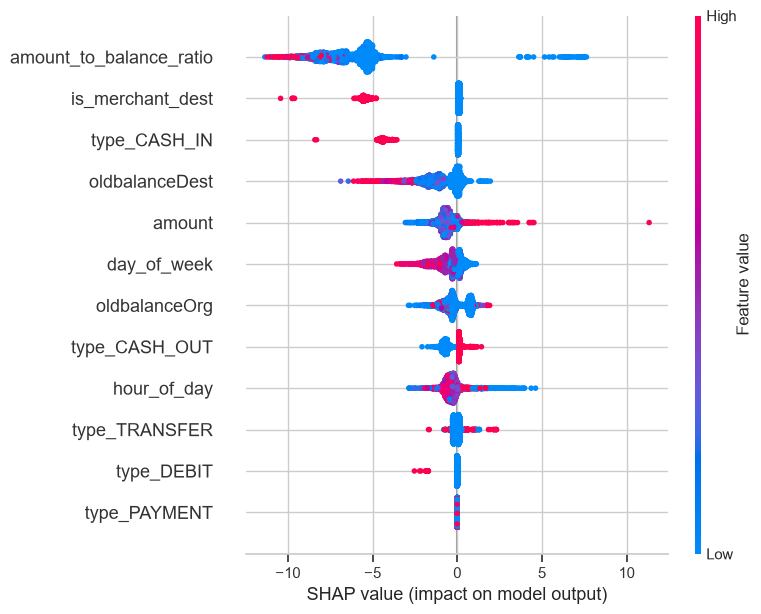

In [8]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=5000, replace=False)

shap.summary_plot(
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    feature_names=feature_columns,
    show=False,
)
plt.tight_layout()
plt.show()

### Reading the comparison

- **`amount_to_balance_ratio` dominates by every method** — 90.1% of gain, and still the single
  largest SHAP contributor, though at a less extreme 47.6% share of total `mean(|SHAP|)`. Same
  driver identified in Phase 3 (PaySim's account-draining fraud pattern), now confirmed a third
  way.
- **SHAP's importance is much more evenly spread across the remaining features than gain's is.**
  Gain concentrates almost everything else into single digits (`is_merchant_dest` 3.2%, `amount`
  2.5%, everything else under 2%), while SHAP spreads real weight across `is_merchant_dest`
  (14.3%), `type_CASH_IN` (7.8%), `oldbalanceDest` (7.3%), `amount` (4.9%), `day_of_week` (4.7%),
  `oldbalanceOrg` (4.4%), `type_CASH_OUT` (4.0%), and `hour_of_day` (3.6%) — eight features all
  landing in a fairly narrow 3.6%-14.3% band. This is an expected consequence of what each metric
  actually measures: gain rewards whichever feature gives the single biggest *average* loss
  improvement at the moment it's split on (dominated by one narrow-band, extremely informative
  feature), while `mean(|SHAP|)` measures how much every feature actually moves *individual*
  predictions away from baseline, which surfaces secondary features' real, if smaller, per-row
  influence more evenly.
- **The most notable rank movements**: `oldbalanceDest` jumps from gain-rank #7 (0.49%) to
  SHAP-rank #4 (7.3%), and `day_of_week` jumps from gain-rank #9 (0.30%) to SHAP-rank #6 (4.7%).
  Both make intuitive sense post hoc — a destination account's pre-existing balance and the day of
  the transaction are exactly the kind of secondary, corroborating signals that would rarely win a
  single best-split competition against `amount_to_balance_ratio`, but still meaningfully nudge
  individual predictions once that dominant feature has already done most of the work.
- **Top-of-list rank order is actually stable**: both gain and SHAP agree `amount_to_balance_ratio`
  is #1 and `is_merchant_dest` is #2 — it's the *magnitude* gap between them that differs sharply
  (gain: 90.1% vs. 3.2%, a ~28x gap; SHAP: 47.6% vs. 14.3%, a ~3.3x gap), not the ranking itself.

## Collinearity resolution: `is_merchant_dest` / `type_PAYMENT`

`CLAUDE.md`'s Phase 3 forward-note flagged this pair as the case SHAP would need to handle more
carefully than raw importance: they are **perfectly collinear** in PaySim (every `PAYMENT`
transaction goes to a merchant and vice versa, zero exceptions), Random Forest split importance
unevenly-but-nonzero between them (0.052 / 0.061), and this XGBoost model routed **all** of that
signal through `is_merchant_dest`, leaving `type_PAYMENT` at **exactly zero** gain/weight
importance.

In [9]:
print("Built-in importance:")
print(f"  type_PAYMENT      gain={comparison_df.loc['type_PAYMENT', 'gain_pct']:.6f}  "
      f"weight={comparison_df.loc['type_PAYMENT', 'weight']:.0f}")
print(f"  is_merchant_dest   gain={comparison_df.loc['is_merchant_dest', 'gain_pct']:.6f}  "
      f"weight={comparison_df.loc['is_merchant_dest', 'weight']:.0f}")

print("\nSHAP mean(|value|):")
print(f"  type_PAYMENT      {comparison_df.loc['type_PAYMENT', 'mean_abs_shap']:.6f}  "
      f"(rank {comparison_df.loc['type_PAYMENT', 'shap_rank']})")
print(f"  is_merchant_dest   {comparison_df.loc['is_merchant_dest', 'mean_abs_shap']:.6f}  "
      f"(rank {comparison_df.loc['is_merchant_dest', 'shap_rank']})")

n_nonzero = int((shap_values[:, feature_columns.index("type_PAYMENT")] != 0).sum())
print(f"\nRows where type_PAYMENT has a nonzero SHAP value: {n_nonzero} / {len(X_test):,}")

Built-in importance:
  type_PAYMENT      gain=0.000000  weight=0
  is_merchant_dest   gain=0.032202  weight=87

SHAP mean(|value|):
  type_PAYMENT      0.000000  (rank 12)
  is_merchant_dest   1.936026  (rank 2)

Rows where type_PAYMENT has a nonzero SHAP value: 0 / 162,021


### The finding: SHAP shows the *same* zero, for a structural reason — not a divergent opinion

**SHAP does not "fix" this instability, and it can't.** `type_PAYMENT`'s `mean(|SHAP|)` is exactly
`0.0` across all 162,021 test rows — identical to its gain and weight importance. This isn't SHAP
independently agreeing with the built-in metrics; it's a mathematical certainty given how this
*specific fitted model* is structured. `weight=0` for `type_PAYMENT` means this XGBoost model
**never once splits on it, in any of its 200 trees**. A feature a model never branches on cannot
change that model's output for any input, and SHAP values measure exactly that — a feature's
actual effect on this model's predictions. Zero effect on the model's output means zero Shapley
value, by definition, regardless of whether the feature carries real-world signal.

**The lesson this generalizes to**: SHAP is a tool for explaining a *fitted model*, not for
recovering the "true" importance of a feature that model happened not to use. If boosting's greedy,
sequential splitting collapses a collinear pair onto one column during training — as it did here —
no post-hoc attribution method, gain-based or Shapley-based, can retroactively find signal in the
column the model ignored. The three models compared across Phases 2-3 (Logistic Regression split
credit evenly via L2's minimum-norm solution under exact collinearity, Random Forest split it
unevenly-but-nonzero via bagging's per-tree randomness, XGBoost collapsed it entirely via
greedy sequential boosting) each reflect a genuine property of *that training algorithm*, not a
difference in how well each one's chosen explanation method can see the truth.

**One place SHAP does add real value here**: unlike the gain/weight table, SHAP puts a number on
*how much* of the model's total decision-making this merchant/non-merchant signal accounts for
overall — 14.3% of total `mean(|SHAP|)`, all routed through `is_merchant_dest` — vs. gain's much
smaller 3.2% share for the same combined signal. So while SHAP can't split credit between the two
collinear columns any more sensibly than gain did, it does reveal that the underlying
merchant-destination signal (whichever column happens to carry it) matters roughly **4.5x more** to
this model's actual predictions than gain-based importance suggested.

**Practical takeaway for reading any future SHAP output on this model (or the dashboard downstream
of it)**: a SHAP summary showing `type_PAYMENT` at zero must not be read as "whether a transaction
is a payment doesn't matter" — it must be read alongside `is_merchant_dest`, its perfectly collinear
partner, which is carrying 100% of that shared signal. This is exactly the caution `CLAUDE.md`'s
forward-note anticipated, now confirmed with hard numbers rather than predicted.

## Local explainability: four individual predictions

One example each of a true positive (correctly caught fraud), false positive, false negative
(missed fraud), and true negative — using the re-derived chosen threshold above. These are exactly
the kind of per-transaction explanation the dashboard will eventually surface, so plain-English
readability matters as much as correctness (see `SHAP_FINDINGS.md` for the write-up aimed at a
non-technical reader).

In [10]:
y_test_arr = y_test.to_numpy()
idx_tp = np.where((y_test_arr == 1) & (preds_chosen == 1))[0][0]
idx_fp = np.where((y_test_arr == 0) & (preds_chosen == 1))[0][0]
idx_fn = np.where((y_test_arr == 1) & (preds_chosen == 0))[0][0]
idx_tn = np.where((y_test_arr == 0) & (preds_chosen == 0))[0][0]

example_indices = {"True Positive": idx_tp, "False Positive": idx_fp, "False Negative": idx_fn, "True Negative": idx_tn}
raw_cols = ["type", "amount", "oldbalanceOrg", "oldbalanceDest"]

for name, idx in example_indices.items():
    raw_row = test_df.iloc[idx]
    print(f"{name} (row {idx}): proba={proba[idx]:.6f}, true label={y_test_arr[idx]}, "
          f"predicted={preds_chosen[idx]}")
    print(f"  {raw_row[raw_cols].to_dict()}")

True Positive (row 172): proba=0.999955, true label=1, predicted=1
  {'type': 'TRANSFER', 'amount': 25040.78, 'oldbalanceOrg': 25040.78, 'oldbalanceDest': 0.0}
False Positive (row 6324): proba=0.993152, true label=0, predicted=1
  {'type': 'CASH_OUT', 'amount': 43446.49, 'oldbalanceOrg': 43574.02, 'oldbalanceDest': 117874.0}
False Negative (row 61953): proba=0.522544, true label=1, predicted=0
  {'type': 'CASH_OUT', 'amount': 40873.25, 'oldbalanceOrg': 40873.25, 'oldbalanceDest': 905220.62}
True Negative (row 0): proba=0.000004, true label=0, predicted=0
  {'type': 'PAYMENT', 'amount': 561.22, 'oldbalanceOrg': 1732.0, 'oldbalanceDest': 0.0}


### True Positive — correctly caught fraud

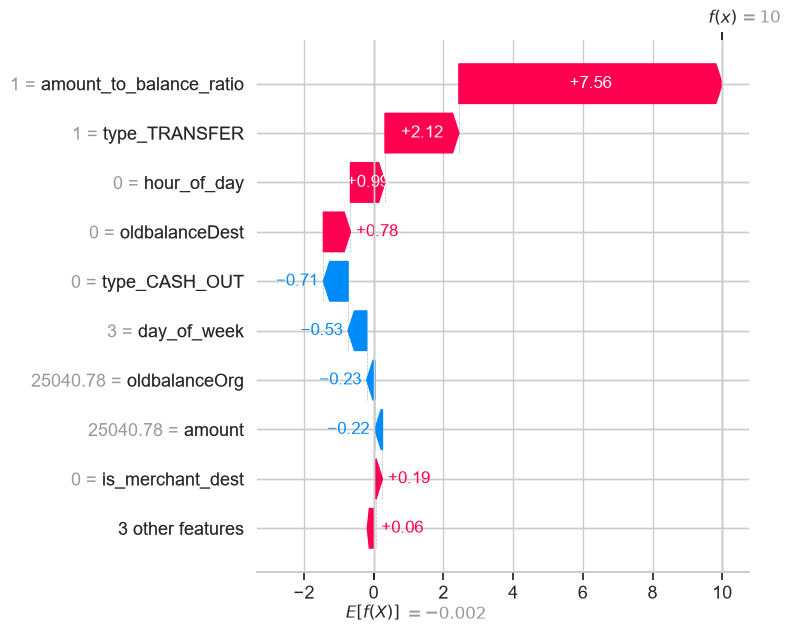

In [11]:
idx = idx_tp
exp = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx].values,
    feature_names=feature_columns,
)
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.show()

### False Positive — a legitimate transaction flagged as fraud

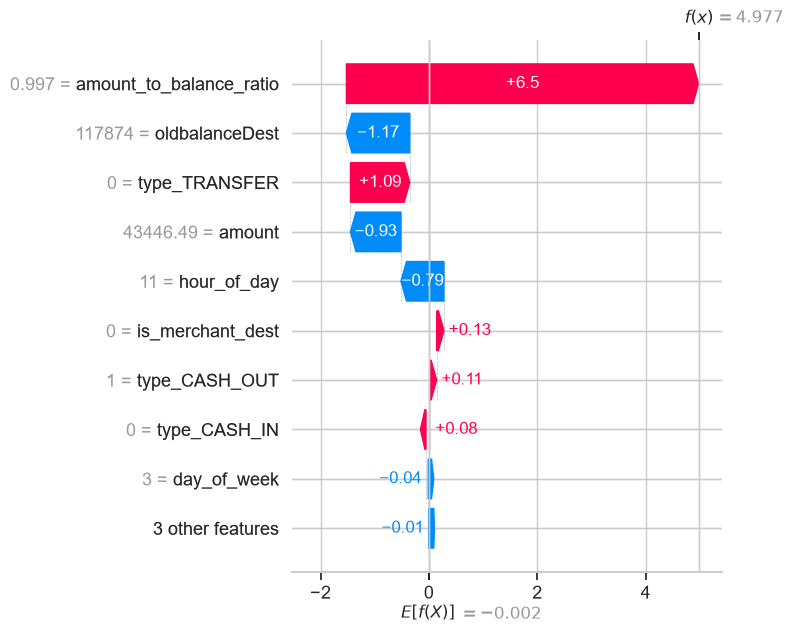

In [12]:
idx = idx_fp
exp = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx].values,
    feature_names=feature_columns,
)
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.show()

### False Negative — fraud that slipped under the threshold

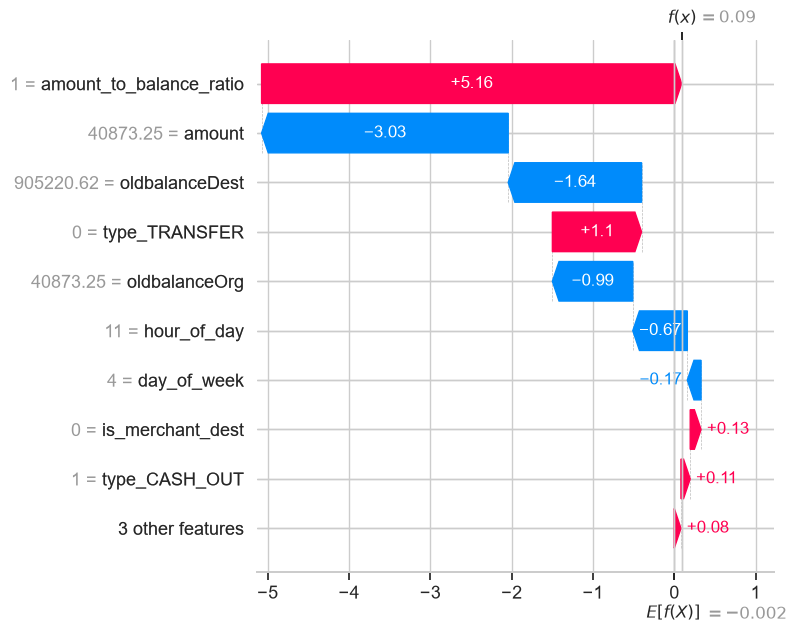

In [13]:
idx = idx_fn
exp = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx].values,
    feature_names=feature_columns,
)
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.show()

### True Negative — an everyday transaction correctly scored as low-risk

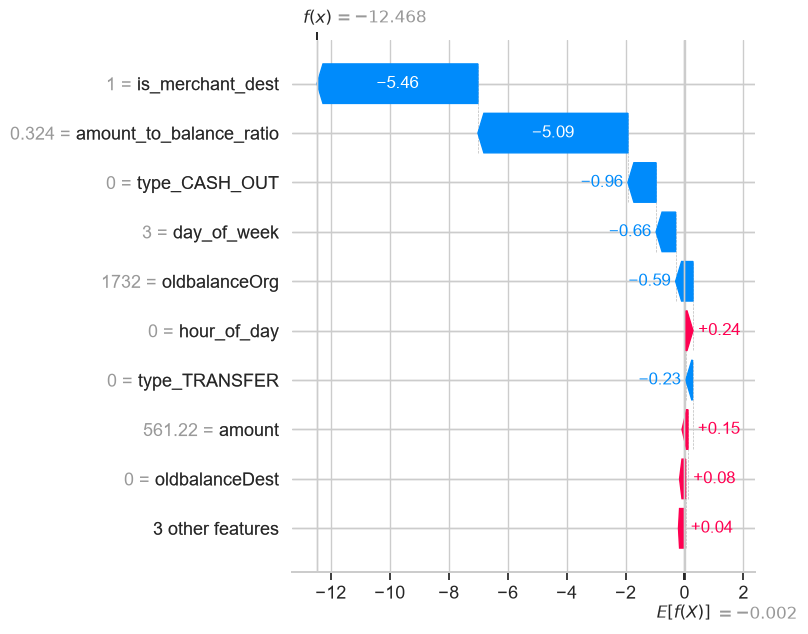

In [14]:
idx = idx_tn
exp = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx].values,
    feature_names=feature_columns,
)
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.show()

## Sanity check against EDA / domain expectations

- **`amount_to_balance_ratio` is the #1 SHAP feature both globally and in every one of the four
  local examples above** — consistent with every prior notebook's finding that this ratio, driven
  by PaySim's account-draining fraud pattern, is the model's dominant signal. Not a surprise, and
  a reassuring consistency check that SHAP isn't disagreeing with the tree-importance story told in
  `PHASE3_FINDINGS.md`.
- **`TRANSFER`/`CASH_OUT` push toward fraud, `CASH_IN`/`is_merchant_dest` push toward legitimacy**
  in the local examples — matches Phase 1 EDA (fraud only ever occurs in `TRANSFER` and `CASH_OUT`
  in PaySim) and the Phase 2 Logistic Regression coefficient sanity check (`TRANSFER`/`CASH_OUT`
  positive, `CASH_IN` strongly negative).
- **The false-negative example is explained by a large, pre-existing destination balance
  (`oldbalanceDest`) pulling the score down** despite an equally extreme `amount_to_balance_ratio`
  as the true-positive example — i.e., the model's main blind spot on this test set isn't a missing
  feature, it's a real fraud transaction that happens to look, on the destination side, like a
  transfer to an established/legitimate-looking account rather than PaySim's typical empty
  drop-account pattern. This is a genuinely useful, dashboard-worthy explanation, not a "the model
  is broken" finding.
- **`type_PAYMENT` never appears with a nonzero SHAP contribution in any of the four examples**
  (including the true-negative `PAYMENT` transaction) — expected and consistent with the
  collinearity finding above, since the true negative's "this looks like an everyday purchase"
  signal is instead carried entirely by `is_merchant_dest`.

## Saving the model and SHAP explainer for backend reuse

**Reuse plan:** the backend (`backend/app/ml/`, once it exists) needs to (1) load the trained
XGBoost model to score an incoming transaction, and (2) reuse the same fitted `TreeExplainer` to
attach a per-transaction explanation to the API response, without retraining or reconstructing
anything at request time.

**What's serialized, and why:**
- `ml/models/xgboost_model.pkl` — the trained `XGBClassifier`, via `pickle`. This is what
  `backend/app/ml/` will actually call `.predict_proba()` on.
- `ml/models/shap_explainer.pkl` — the fitted `shap.TreeExplainer`, also via plain `pickle`.
  Verified to round-trip correctly (identical SHAP values before and after a `pickle.dumps` /
  `pickle.loads` cycle) before relying on it here. `TreeExplainer` needs no background dataset in
  the default `tree_path_dependent` mode used throughout this notebook, so — unlike
  `KernelExplainer` — there's no separate reference/background sample to ship alongside it.
- `ml/models/model_metadata.json` — `feature_columns` (the exact, ordered list
  `build_features()` produces), the chosen `threshold`, and the training hyperparameters. The
  backend needs the exact feature order to build a same-shaped row for a single incoming
  transaction via the shared `preprocessing.build_features()`; hardcoding or re-deriving it
  separately in `backend/` would risk silent drift from what the model was actually trained on.

**What would need to change to call this from FastAPI:**
1. Load `xgboost_model.pkl`, `shap_explainer.pkl`, and `model_metadata.json` once at app startup
   (e.g. in a module-level singleton or a FastAPI lifespan/dependency), not per-request — both
   pickle loads are cheap, but there's no reason to repeat them per request.
2. Per incoming transaction: run it through the same `preprocessing.build_features()` used here
   (already designed for exactly this — see its docstring: `y` is `None` when `isFraud` isn't
   present, which is always true for a real, unlabeled, real-time transaction) to get a
   single-row `X`, matching `model_metadata.json`'s `feature_columns` order.
3. Call `model.predict_proba(X)[:, 1]` for the fraud score, compare against
   `model_metadata.json`'s `threshold` for the flag decision, and call
   `explainer.shap_values(X)` for that row's per-feature contributions to attach to the response
   (e.g. as a `{feature: contribution}` map, or converted into the handful of top contributors
   for a human-readable dashboard explanation, following the plain-English pattern in
   `SHAP_FINDINGS.md`).
4. **Interpretation note for whoever writes that response**: per the collinearity finding above,
   any consumer of per-feature SHAP contributions (the dashboard included) needs to know
   `is_merchant_dest` carries 100% of the merchant/payment-type signal and `type_PAYMENT` will
   always show zero — worth a short comment in that backend code pointing back here, so a future
   reader doesn't mistake it for a bug.
5. Retraining: if the model is ever retrained (new data, tuned hyperparameters), both
   `xgboost_model.pkl` and `shap_explainer.pkl` must be regenerated together — an explainer
   pickled against an old model would silently produce explanations for the wrong model if only
   one of the two files were swapped.

In [15]:
MODELS_DIR = REPO_ROOT / "ml" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(MODELS_DIR / "xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

with open(MODELS_DIR / "shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

metadata = {
    "feature_columns": feature_columns,
    "threshold": float(CHOSEN_THRESHOLD),
    "hyperparameters": {
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "scale_pos_weight": float(scale_pos_weight),
        "random_state": RANDOM_STATE,
    },
    "split_cutoff_step": int(cutoff_used),
    "pr_auc_test": float(pr_auc),
}
with open(MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Round-trip check: a pickled explainer should reproduce identical SHAP values.
with open(MODELS_DIR / "shap_explainer.pkl", "rb") as f:
    explainer_reloaded = pickle.load(f)
shap_values_reloaded = explainer_reloaded.shap_values(X_test.iloc[:50])
assert np.allclose(shap_values_reloaded, shap_values[:50]), "Reloaded explainer does not match"

print("Saved to ml/models/:")
for p in ["xgboost_model.pkl", "shap_explainer.pkl", "model_metadata.json"]:
    size_kb = (MODELS_DIR / p).stat().st_size / 1024
    print(f"  {p}  ({size_kb:.1f} KB)")
print("\nRound-trip check passed: reloaded explainer reproduces identical SHAP values.")

Saved to ml/models/:
  xgboost_model.pkl  (586.7 KB)
  shap_explainer.pkl  (2090.6 KB)
  model_metadata.json  (0.6 KB)

Round-trip check passed: reloaded explainer reproduces identical SHAP values.


## Summary

Full write-up — global importance comparison, the collinearity resolution finding, and three
example local explanations in plain English — is in `SHAP_FINDINGS.md`. Isolation Forest anomaly
detection remains the other piece of Phase 4 and is not attempted in this notebook. Backend
integration (`backend/app/ml/`) and the frontend dashboard are next, per `CLAUDE.md`'s "Next
Recommended Work" — both can now load `ml/models/xgboost_model.pkl` and
`ml/models/shap_explainer.pkl` directly rather than retraining.